# RNN Day 1 Housing Data

### Importing Libraries

In [ ]:
import pandas as pd                                 # table/dataframe handling
import numpy as np                                  # numerical operations
import matplotlib.pyplot as plt                     # plotting

from sklearn.preprocessing import MinMaxScaler      # scales values to 0-1 range
from sklearn.metrics import mean_absolute_error, mean_squared_error
                                                    # RMSE and MAE calculation

import tensorflow as tf
import random

from tensorflow.keras.models import Sequential      # sequential neural network API

from tensorflow.keras.layers import (
    Dense,                                          # standard fully connected layer
    SimpleRNN,                                      # recurrent neural network layer
    Conv1D,                                         # 1D convolution layer
    Flatten                                         # flatten multidimensional output
)

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

### Loading the data

In [ ]:
house = pd.read_csv("ma_lga_12345.csv")   # load housing dataset

house.head()                              # inspect first few rows

,saledate,MA,type,bedrooms
0,30/09/2007,441854,house,2
1,31/12/2007,441854,house,2
2,31/03/2008,441854,house,2
3,30/06/2008,441854,house,2
4,30/09/2008,451583,house,2


### Inspecting the temporal nature of the data

In [ ]:
print(house.shape)            # number of rows and columns
print(house.dtypes)           # variable data types
print(house.isna().sum())     # missing values per column

house.describe()              # summary statistics

(347, 4)
saledate    object
MA           int64
type        object
bedrooms     int64
dtype: object
saledate    0
MA          0
type        0
bedrooms    0
dtype: int64


,MA,bedrooms
count,3.470000e+02,347.000000
mean,5.481320e+05,2.867435
std,1.701934e+05,1.239875
min,3.167510e+05,1.000000
25%,4.277395e+05,2.000000
50%,5.077440e+05,3.000000
75%,6.275155e+05,4.000000
max,1.017752e+06,5.000000


## Defining useful functions


Formatting data for rolling windows

In [ ]:
def create_sequences(dataset, look_back=2):

    X, y = [], []                          # containers for windows and targets

    for i in range(len(dataset) - look_back):

        X.append(dataset[i:i + look_back, :])   # rolling window
        y.append(dataset[i + look_back, 0])     # next timestep target

    return np.array(X), np.array(y)

Plotting training curves

In [ ]:
def plot_training_curves(history, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="Training Loss")
    axes[0].plot(history.history["val_loss"], label="Validation Loss")
    axes[0].set_title(title + " Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].set_ylim(0, 0.4)
    axes[0].legend()

    axes[1].plot(history.history["mean_absolute_error"], label="Training MAE")
    axes[1].plot(history.history["val_mean_absolute_error"], label="Validation MAE")
    axes[1].set_title(title + " MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Mean Absolute Error")
    axes[1].set_ylim(0, 0.65)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

Evaluating model performance on test data

In [ ]:
def evaluate_and_plot(model, trainX, testX, trainY, testY, scaler, title):

    # Make predictions
    train_pred = model.predict(trainX)
    test_pred = model.predict(testX)

    # Convert scaled values back to original MA scale
    train_pred_inv = scaler.inverse_transform(train_pred)
    test_pred_inv = scaler.inverse_transform(test_pred)
    trainY_inv = scaler.inverse_transform(trainY.reshape(-1, 1))
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    # Calculate RMSE on original scale
    train_rmse = np.sqrt(mean_squared_error(trainY_inv, train_pred_inv))
    test_rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))

    print(f"{title} Train RMSE: {train_rmse:.2f}")
    print(f"{title} Test RMSE: {test_rmse:.2f}")

    # Plot held-out future test predictions
    plt.figure(figsize=(10, 4))
    plt.plot(testY_inv, label="Actual")
    plt.plot(test_pred_inv, label="Predicted")

    plt.title(title + " Test Predictions")
    plt.xlabel("Test time index")
    plt.ylabel("MA")
    plt.ylim(0, 1200000)
    plt.ticklabel_format(style="plain", axis="y")
    plt.legend()
    plt.show()

Comparing forcasting performance metrics

In [ ]:

def evaluate_metrics(model, testX, testY, scaler):

    test_pred = model.predict(testX)

    test_pred_inv = scaler.inverse_transform(test_pred)
    testY_inv = scaler.inverse_transform(testY.reshape(-1, 1))

    rmse = np.sqrt(mean_squared_error(testY_inv, test_pred_inv))
    mae = mean_absolute_error(testY_inv, test_pred_inv)

    return rmse, mae

### Initial RNN & Performance

In [ ]:
# Initial RNN

ma_sequence = house.copy()
ma_sequence = ma_sequence.sort_values("saledate").reset_index(drop=True)
                                                                # preserve chronological order

df_initial = ma_sequence[["MA"]].copy()                         # univariate forecasting feature

scaler_initial = MinMaxScaler(feature_range=(0, 1))
scaled_initial = scaler_initial.fit_transform(df_initial)
                                                                # neural networks train better on scaled values

look_back = 2                                                   # use previous 2 timesteps to predict next timestep

train_size = int(len(scaled_initial) * 0.8)

train_initial = scaled_initial[:train_size]                     # earlier historical data
test_initial = scaled_initial[train_size:]                      # held-out future data

trainX_initial, trainY_initial = create_sequences(
    train_initial,
    look_back
)                                                               # rolling training windows

testX_initial, testY_initial = create_sequences(
    test_initial,
    look_back
)                                                               # rolling future test windows

print("trainX shape:", trainX_initial.shape)
print("testX shape:", testX_initial.shape)

initial_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_initial.shape[2])
    ),                                                          # recurrent hidden layer

    Dense(1)                                                    # regression output layer
])

initial_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

initial_history = initial_model.fit(
    trainX_initial,
    trainY_initial,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                                              # preserve temporal order
    verbose=1
)

trainX shape: (275, 2, 1)
testX shape: (68, 2, 1)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.1027 - mean_absolute_error: 0.2647 - val_loss: 0.0916 - val_mean_absolute_error: 0.2549
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0868 - mean_absolute_error: 0.2409 - val_loss: 0.0807 - val_mean_absolute_error: 0.2324
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0758 - mean_absolute_error: 0.2230 - val_loss: 0.0740 - val_mean_absolute_error: 0.2187
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0682 - mean_absolute_error: 0.2089 - val_loss: 0.0702 - val_mean_absolute_error: 0.2103
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0633 - mean_absolute_error: 0.1992 - val_loss: 0.0686 - val_mean_absolute_error: 0.2046
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0602 - mean_absolute_error: 0.1938 - val_loss: 0.0682 - val_mean_absolute_error: 0.2039
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0583 - mean_absolute_error: 0.1910 - val_loss: 0.0685 - 

Training curves

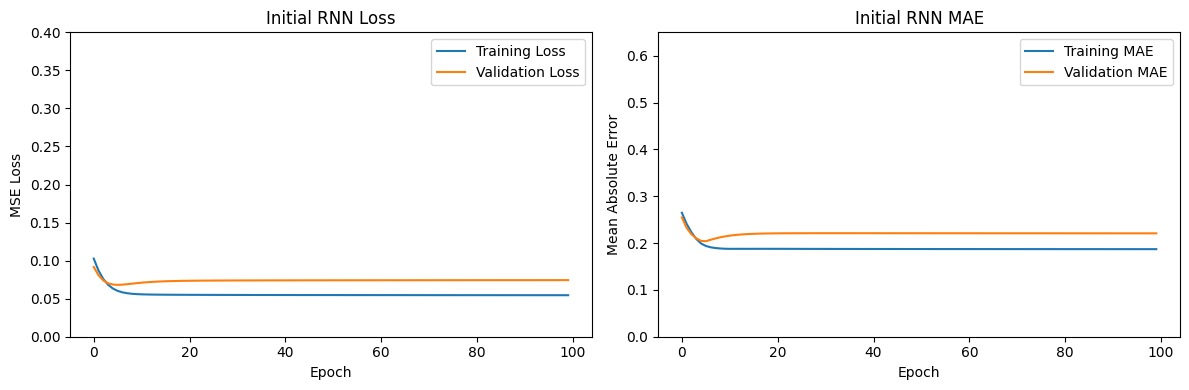

In [ ]:
plot_training_curves(
    initial_history,
    "Initial RNN"
)

Test data evaluation

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Initial RNN Train RMSE: 168752.01
Initial RNN Test RMSE: 171397.52


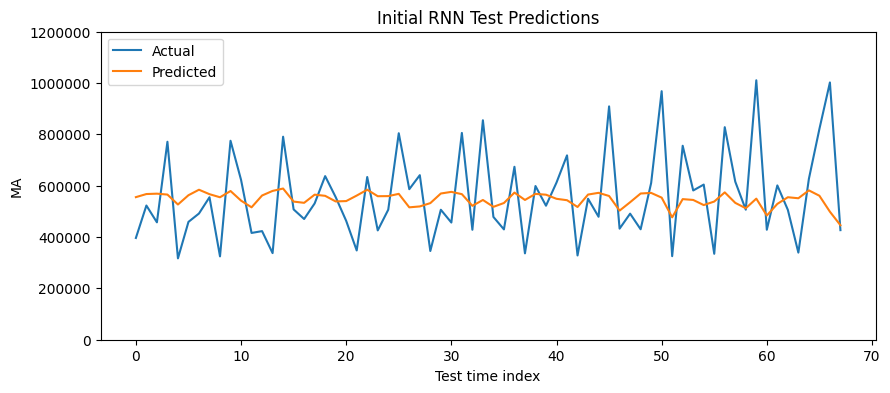

In [ ]:
evaluate_and_plot(
    initial_model,
    trainX_initial,
    testX_initial,
    trainY_initial,
    testY_initial,
    scaler_initial,
    "Initial RNN"
)

### Initial MA data re-evaluation

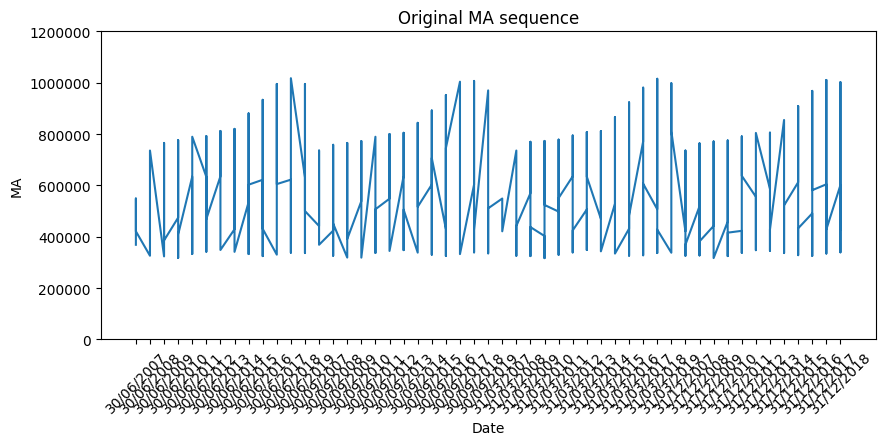

In [ ]:
# Plot the original MA sequence exactly as provided

plt.figure(figsize=(10, 4))

plt.plot(
    ma_sequence["saledate"],
    ma_sequence["MA"]
)

plt.title("Original MA sequence")
plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.xticks(rotation=45)

plt.show()


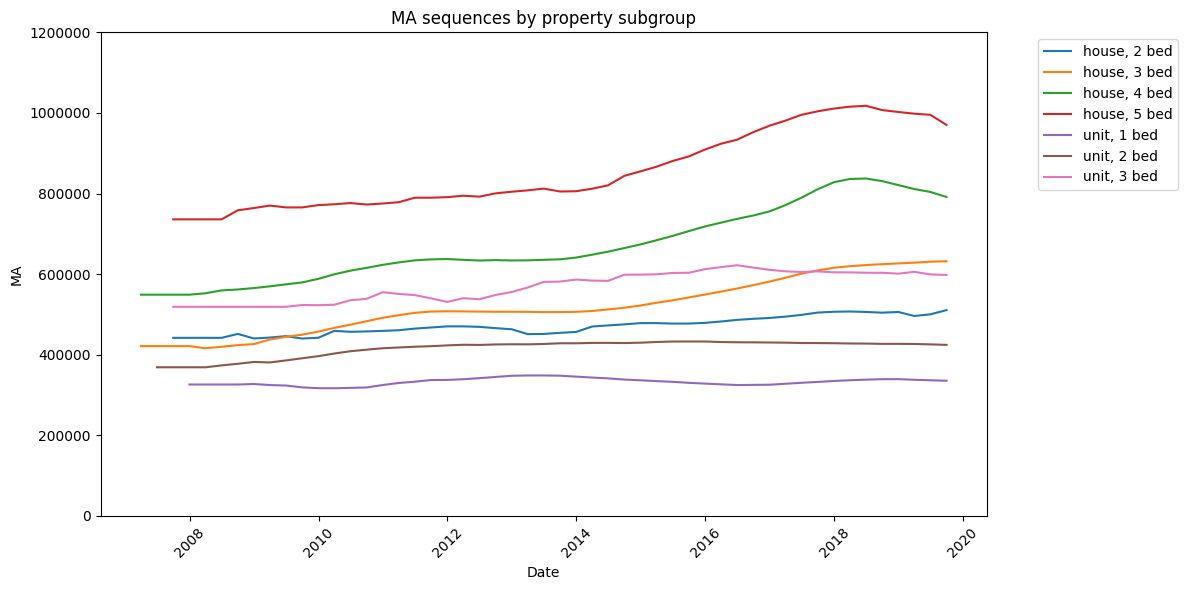

In [ ]:
# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

# Plot each subgroup MA sequence separately

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)

plt.figure(figsize=(12, 6))

for (property_type, bedrooms), group in house.groupby(["type", "bedrooms"]):

    group = group.sort_values("saledate")      # chronological ordering

    plt.plot(
        group["saledate"],
        group["MA"],
        label=f"{property_type}, {bedrooms} bed"
    )

plt.title("MA sequences by property subgroup")

plt.xlabel("Date")
plt.ylabel("MA")

plt.ylim(0, 1200000)

plt.ticklabel_format(
    style='plain',
    axis='y'
)

plt.xticks(rotation=45)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

Inspecting the first window

In [ ]:
print("trainX_initial shape:", trainX_initial.shape)

window_id = 0

ma_sequence.iloc[
    window_id : window_id + look_back + 1
][["saledate", "type", "bedrooms", "MA"]]

trainX_initial shape: (275, 2, 1)


,saledate,type,bedrooms,MA
0,30/06/2007,unit,2,368817
1,30/06/2007,house,4,548969
2,30/06/2007,house,3,421291


### Creating market-level MA data

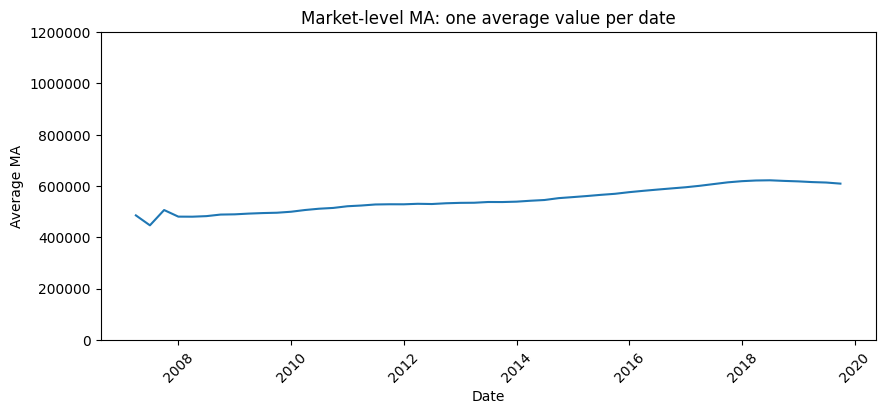

In [ ]:
# Create market-level MA sequence

house["saledate"] = pd.to_datetime(
    house["saledate"],
    dayfirst=True
)                                                    # ensure dates sort chronologically

market_ma = (
    house
    .groupby("saledate")["MA"]
    .mean()
    .reset_index()
    .sort_values("saledate")
    .reset_index(drop=True)
)                                                    # average subgroup MAs per date

# Visualize market-level MA

plt.figure(figsize=(10, 4))

plt.plot(
    market_ma["saledate"],
    market_ma["MA"]
)

plt.title("Market-level MA: one average value per date")
plt.xlabel("Date")
plt.ylabel("Average MA")

plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)

plt.show()

### Preparing market-level MA data for variety of models

In [ ]:
# Prepare market-level MA data for all fixed-data models

df_market = market_ma[["MA"]].copy()                            # cleaned one-value-per-date MA series

scaler_market = MinMaxScaler(feature_range=(0, 1))              # scale MA values for neural networks
scaled_market = scaler_market.fit_transform(df_market)

look_back = 2                                                   # use 2 previous timesteps to predict next timestep

train_size = int(len(scaled_market) * 0.8)                      # chronological 80/20 split

train_market = scaled_market[:train_size]                       # earlier historical data
test_market = scaled_market[train_size:]                        # held-out future data

trainX_market, trainY_market = create_sequences(
    train_market,
    look_back
)                                                               # sequence windows for RNN/CNN

testX_market, testY_market = create_sequences(
    test_market,
    look_back
)                                                               # future test windows for RNN/CNN

trainX_market_mlp = trainX_market.reshape(
    trainX_market.shape[0],
    trainX_market.shape[1] * trainX_market.shape[2]
)                                                               # flattened windows for MLP

testX_market_mlp = testX_market.reshape(
    testX_market.shape[0],
    testX_market.shape[1] * testX_market.shape[2]
)                                                               # flattened test windows for MLP

print("RNN/CNN trainX_market shape:", trainX_market.shape)
print("RNN/CNN testX_market shape:", testX_market.shape)

print("MLP trainX_market_mlp shape:", trainX_market_mlp.shape)
print("MLP testX_market_mlp shape:", testX_market_mlp.shape)

RNN/CNN trainX_market shape: (38, 2, 1)
RNN/CNN testX_market shape: (9, 2, 1)
MLP trainX_market_mlp shape: (38, 2)
MLP testX_market_mlp shape: (9, 2)


### Inspecting the tensors

Shape & window 0 values

In [ ]:
print("trainX_market shape:", trainX_market.shape)

window_id = 0

market_ma.iloc[
    window_id : window_id + look_back + 1
][["saledate", "MA"]]

trainX_market shape: (38, 2, 1)


,saledate,MA
0,2007-03-31,485130.000000
1,2007-06-30,446359.000000
2,2007-09-30,505957.666667


Scale window 0

In [ ]:
# Visualize one input window and its target

window_id = 0

print("Input window:")
print(trainX_market[window_id].flatten())

print("Target:")
print(trainY_market[window_id])

Input window:
[0.22095731 0.        ]
Target:
0.33965492068299463


### Market-level RNN model & evaluation

In [ ]:
# Build and train market-level RNN model

market_rnn_model = Sequential([
    SimpleRNN(
        16,
        activation="tanh",
        input_shape=(look_back, trainX_market.shape[2])
    ),
    Dense(1)
])

market_rnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_rnn_history = market_rnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0500 - mean_absolute_error: 0.2169 - val_loss: 0.1204 - val_mean_absolute_error: 0.3453
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0223 - mean_absolute_error: 0.1427 - val_loss: 0.0597 - val_mean_absolute_error: 0.2425
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0068 - mean_absolute_error: 0.0768 - val_loss: 0.0229 - val_mean_absolute_error: 0.1492
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0017 - mean_absolute_error: 0.0272 - val_loss: 0.0061 - val_mean_absolute_error: 0.0754
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0028 - mean_absolute_error: 0.0423 - val_loss: 0.0013 - val_mean_absolute_error: 0.0306
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0049 - mean_absolute_error: 0.0608 - val_loss: 6.6129e-04 - val_mean_absolute_error: 0.0215
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0052 - mean_absolute_error: 0.0612 - val_loss: 0.0013 - val

Training curves

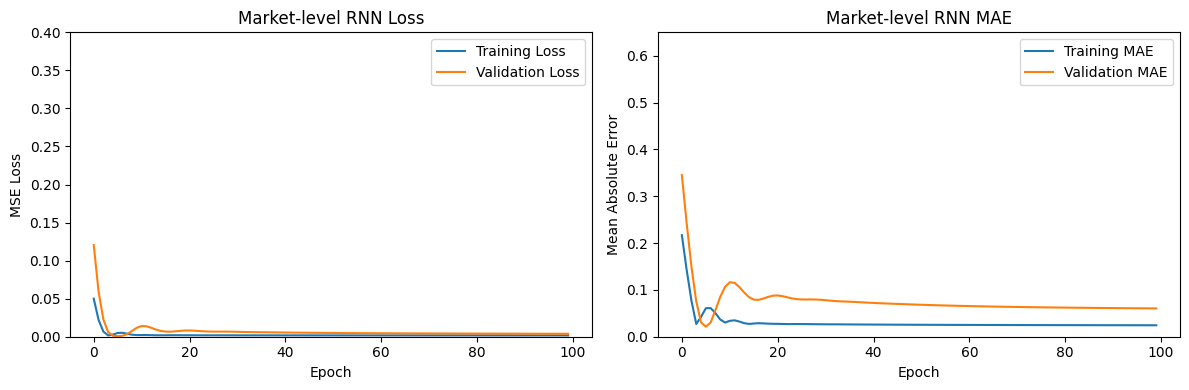

In [ ]:
plot_training_curves(
    market_rnn_history,
    "Market-level RNN"
)

Test data evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Market-level RNN Train RMSE: 8131.16
Market-level RNN Test RMSE: 15985.00


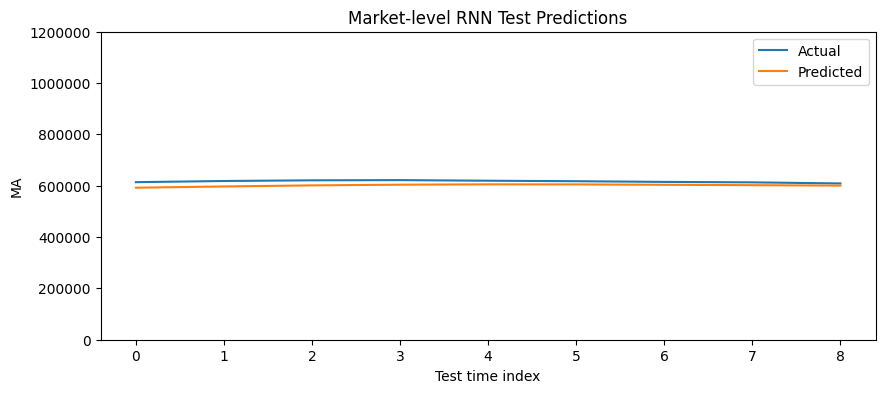

In [ ]:
evaluate_and_plot(
    market_rnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level RNN"
)

### Market level MLP and evaluation

In [ ]:
# Build and train market-level MLP model

market_mlp_model = Sequential([
    Dense(
        32,
        activation="relu",
        input_shape=(trainX_market_mlp.shape[1],)
    ),
    Dense(
        16,
        activation="relu"
    ),
    Dense(1)
])

market_mlp_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_mlp_history = market_mlp_model.fit(
    trainX_market_mlp,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0963 - mean_absolute_error: 0.2989 - val_loss: 0.2720 - val_mean_absolute_error: 0.5195
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0762 - mean_absolute_error: 0.2646 - val_loss: 0.2254 - val_mean_absolute_error: 0.4728
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0604 - mean_absolute_error: 0.2341 - val_loss: 0.1870 - val_mean_absolute_error: 0.4305
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0456 - mean_absolute_error: 0.2016 - val_loss: 0.1498 - val_mean_absolute_error: 0.3851
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0322 - mean_absolute_error: 0.1670 - val_loss: 0.1146 - val_mean_absolute_error: 0.3366
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0213 - mean_absolute_error: 0.1330 - val_loss: 0.0845 - val_mean_absolute_error: 0.2888
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0130 - mean_absolute_error: 0.1011 - val_loss: 0.0601 - val_mean

Training curves MLP

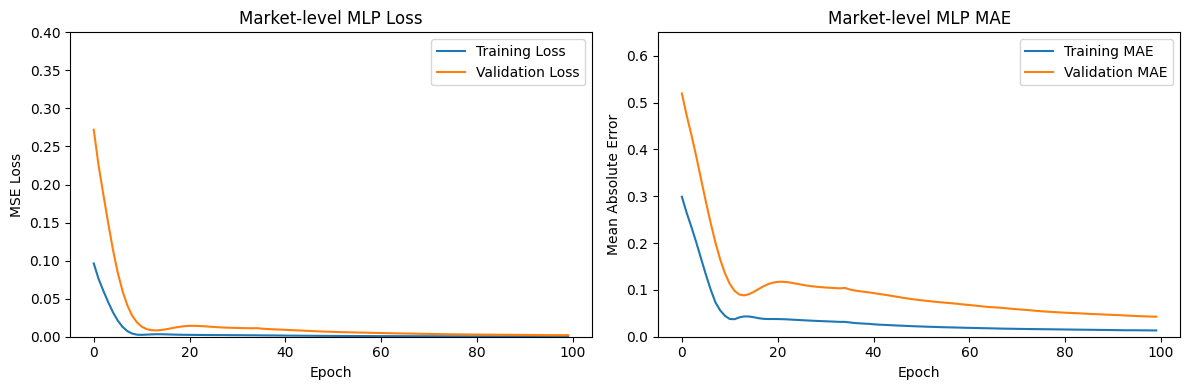

In [ ]:
plot_training_curves(
    market_mlp_history,
    "Market-level MLP"
)

Test data evaluation MLP

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Market-level MLP Train RMSE: 4631.41
Market-level MLP Test RMSE: 10526.73


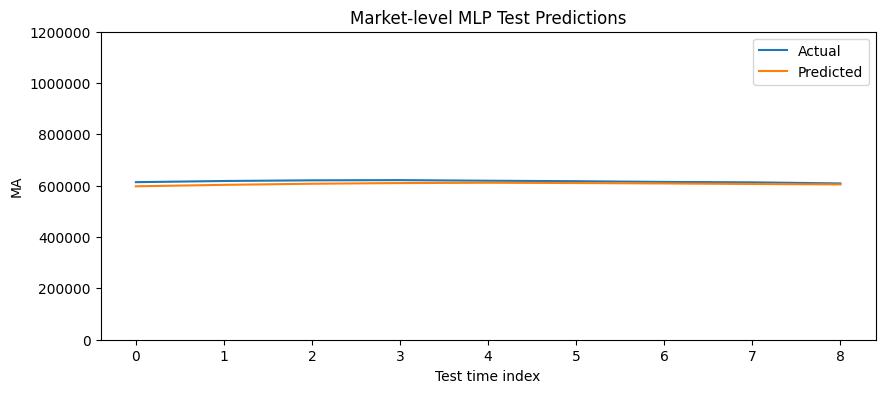

In [ ]:
evaluate_and_plot(
    market_mlp_model,
    trainX_market_mlp,
    testX_market_mlp,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level MLP"
)

### Market level CNN & evaluation

In [ ]:
# Build and train market-level 1D CNN model

market_cnn_model = Sequential([
    Conv1D(
        filters=16,                         # learn 16 temporal pattern detectors
        kernel_size=2,                      # each filter looks across 2 neighboring timesteps
        activation="relu",
        input_shape=(look_back, trainX_market.shape[2])
    ),                                      # input shape = timesteps, features

    Flatten(),                              # convert CNN output to flat vector for Dense layer

    Dense(1)                                # regression output layer
])

market_cnn_model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

market_cnn_history = market_cnn_model.fit(
    trainX_market,
    trainY_market,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,                          # preserve temporal order
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.0999 - mean_absolute_error: 0.3029 - val_loss: 0.2975 - val_mean_absolute_error: 0.5433
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0884 - mean_absolute_error: 0.2840 - val_loss: 0.2710 - val_mean_absolute_error: 0.5184
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0778 - mean_absolute_error: 0.2656 - val_loss: 0.2458 - val_mean_absolute_error: 0.4937
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0681 - mean_absolute_error: 0.2474 - val_loss: 0.2222 - val_mean_absolute_error: 0.4693
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0592 - mean_absolute_error: 0.2297 - val_loss: 0.2003 - val_mean_absolute_error: 0.4455
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0514 - mean_absolute_error: 0.2127 - val_loss: 0.1801 - val_mean_absolute_error: 0.4224
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0445 - mean_absolute_error: 0.1967 - val_loss: 0.1618 - val_mean

Training curves 1D CNN

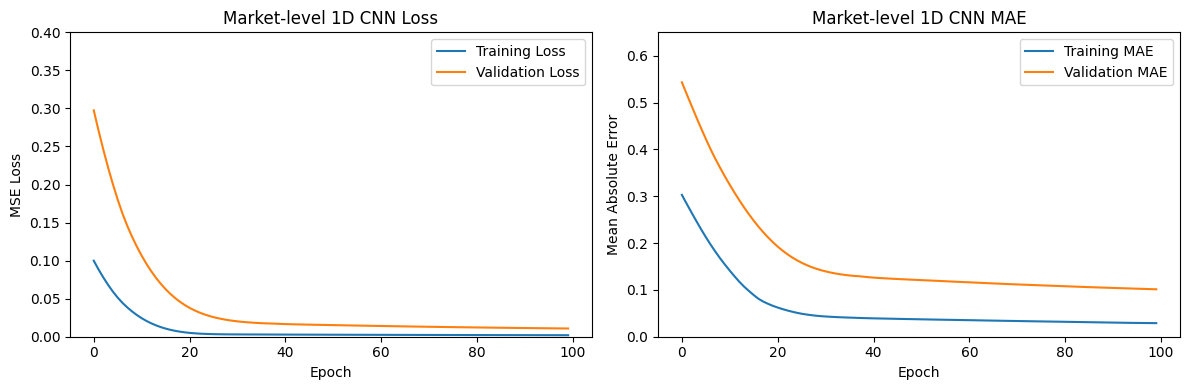

In [ ]:
plot_training_curves(
    market_cnn_history,
    "Market-level 1D CNN"
)

Test data evaluation 1D CNN

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Market-level 1D CNN Train RMSE: 10858.95
Market-level 1D CNN Test RMSE: 27010.29


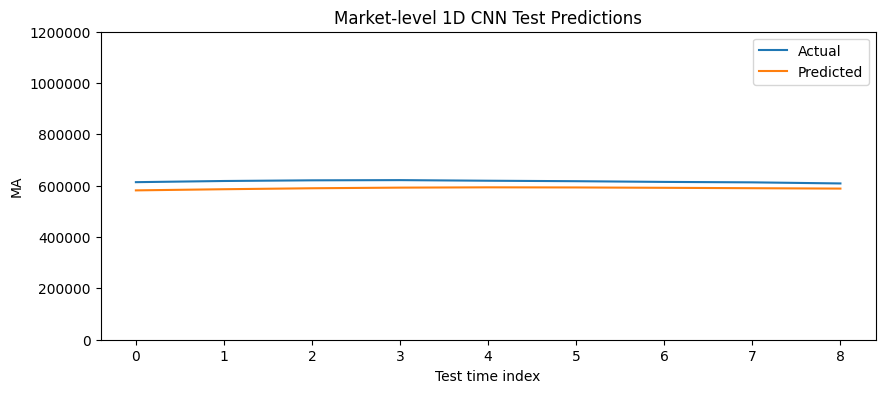

In [ ]:
evaluate_and_plot(
    market_cnn_model,
    trainX_market,
    testX_market,
    trainY_market,
    testY_market,
    scaler_market,
    "Market-level 1D CNN"
)

### Comparison of RNN vs MLP vs 1D CNN

In [ ]:
rnn_rmse, rnn_mae = evaluate_metrics(
    market_rnn_model,
    testX_market,
    testY_market,
    scaler_market
)

mlp_rmse, mlp_mae = evaluate_metrics(
    market_mlp_model,
    testX_market_mlp,
    testY_market,
    scaler_market
)

cnn_rmse, cnn_mae = evaluate_metrics(
    market_cnn_model,
    testX_market,
    testY_market,
    scaler_market
)

comparison = pd.DataFrame({
    "Model": ["RNN", "MLP", "1D CNN"],
    "RMSE": [rnn_rmse, mlp_rmse, cnn_rmse],
    "MAE": [rnn_mae, mlp_mae, cnn_mae]
})

comparison

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


,Model,RMSE,MAE
0,RNN,15985.004700,15295.120040
1,MLP,10526.726267,9675.571429
2,1D CNN,27010.286225,26676.696429


### Your Turn — Build and Compare RNN Models

Choose one or more coherent housing subgroups (for example, 3-bedroom houses) and build at least 3 meaningfully different RNN forecasting models. Evaluate each model using training/validation curves, held-out future test predictions, RMSE, and MAE, and record your observations in markdown cells throughout the notebook.

### Model Exploration Summary

**Subgroup explored:** 3-bedroom houses — aggregated to one average MA per date, giving a clean univariate time series free of subgroup mixing. 51 total timesteps; 80/20 chronological split.

**Model variations:**

| Model | Architecture | look\_back | Units | Test RMSE | Test MAE |
|-------|-------------|-----------|-------|-----------|---------|
| M1 | Baseline SimpleRNN | 2 | 16 | 15,822 | 15,778 |
| M2 | Wider SimpleRNN | 4 | 32 | 21,124 | 21,081 |
| M3 | Stacked SimpleRNN (two layers) | 4 | 32 → 16 | **6,110** | **6,004** |
| M4 | SimpleRNN + Dropout(0.2) | 4 | 32 | 12,080 | 11,982 |

**What appeared to improve performance:**
- Stacking two SimpleRNN layers (M3) produced by far the lowest RMSE and MAE, cutting error roughly 60% compared to the baseline. The hierarchical hidden-state representations appear to better capture the trend structure in this subgroup.
- Dropout (M4) improved over the plain wider model (M2), confirming that regularization helps when capacity is increased on a small dataset.

**What appeared to worsen or add no value:**
- Increasing look_back from 2 to 4 with more units (M2) actually hurt performance relative to M1 — RMSE rose from ~15,800 to ~21,100. On only ~36 training windows, the additional capacity appears to overfit without the depth of M3 to form useful abstractions.

**Training curve observations:**
- M1 and M2 showed relatively stable convergence, though M2's validation loss was less smooth — consistent with the higher test error.
- M3's training curves showed the most rapid loss reduction, and validation loss tracked training loss reasonably well despite the deeper architecture.
- M4's curves were smoother than M2's, confirming dropout's regularizing effect, though it did not fully close the gap with M3.

**Best model:** M3 (Stacked SimpleRNN) — RMSE of ~6,100 on the held-out test set, roughly 60% lower than the baseline. Note that the test set contains only 7 windows, so these metrics are noisy; results would vary across random seeds.

### Subgroup Selection and Data Preparation

The initial RNN above treated all property types and bedroom counts as one interleaved sequence — mixing signals from fundamentally different market segments. Below we isolate **3-bedroom houses**, the largest and most liquid subgroup in this dataset, and build a clean one-value-per-date MA series before training four progressively different models.

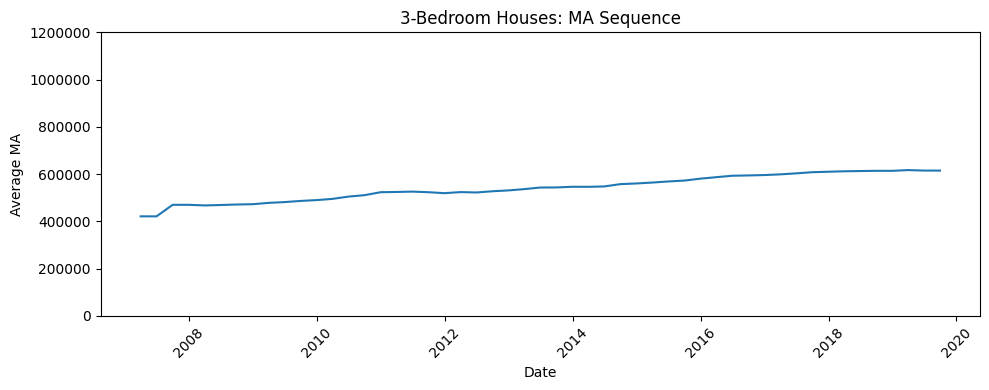

Timesteps available: 51
Train timesteps: 40  |  Test timesteps: 11


In [ ]:
from tensorflow.keras.layers import Dropout

# Filter to 3-bedroom houses and aggregate one MA per date
house_3bed = house[house["bedrooms"] == 3].copy()

ma_3bed = (
    house_3bed
    .groupby("saledate")["MA"]
    .mean()
    .reset_index()
    .sort_values("saledate")
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 4))
plt.plot(ma_3bed["saledate"], ma_3bed["MA"])
plt.title("3-Bedroom Houses: MA Sequence")
plt.xlabel("Date")
plt.ylabel("Average MA")
plt.ylim(0, 1200000)
plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Timesteps available: {len(ma_3bed)}")

# Scale and chronological 80/20 split — shared across all 4 models
df_3bed = ma_3bed[["MA"]].copy()
scaler_3bed = MinMaxScaler(feature_range=(0, 1))
scaled_3bed = scaler_3bed.fit_transform(df_3bed)

train_size_3bed = int(len(scaled_3bed) * 0.8)
train_3bed = scaled_3bed[:train_size_3bed]
test_3bed  = scaled_3bed[train_size_3bed:]

print(f"Train timesteps: {train_size_3bed}  |  Test timesteps: {len(test_3bed)}")

### Model 1 — Baseline SimpleRNN (look\_back = 2, 16 units)

The same architecture used for the market-level data above, now applied to the cleaner 3-bedroom subgroup series. This sets a performance baseline that every subsequent model should improve on.

In [ ]:
# Model 1: Baseline SimpleRNN — look_back=2, 16 units
look_back_1 = 2

trainX_1, trainY_1 = create_sequences(train_3bed, look_back_1)
testX_1, testY_1   = create_sequences(test_3bed,  look_back_1)

print("trainX shape:", trainX_1.shape, " | testX shape:", testX_1.shape)

model_1 = Sequential([
    SimpleRNN(16, activation="tanh", input_shape=(look_back_1, 1)),
    Dense(1)
])

model_1.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

history_1 = model_1.fit(
    trainX_1, trainY_1,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

trainX shape: (38, 2, 1)  | testX shape: (9, 2, 1)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - loss: 0.0056 - mean_absolute_error: 0.0601 - val_loss: 0.0039 - val_mean_absolute_error: 0.0601
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0029 - mean_absolute_error: 0.0342 - val_loss: 2.0027e-04 - val_mean_absolute_error: 0.0124
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0035 - mean_absolute_error: 0.0473 - val_loss: 4.4490e-04 - val_mean_absolute_error: 0.0171
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0025 - mean_absolute_error: 0.0339 - val_loss: 0.0034 - val_mean_absolute_error: 0.0565
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0025 - mean_absolute_error: 0.0322 - val_loss: 0.0066 - val_mean_absolute_error: 0.0794
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0025 - mean_absolute_error: 0.0316 - val_loss: 0.0054 - val_mean_absolute_error: 0.0717
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0021 - mean_absolute_error: 0.0277 - val_loss: 0.0030 -

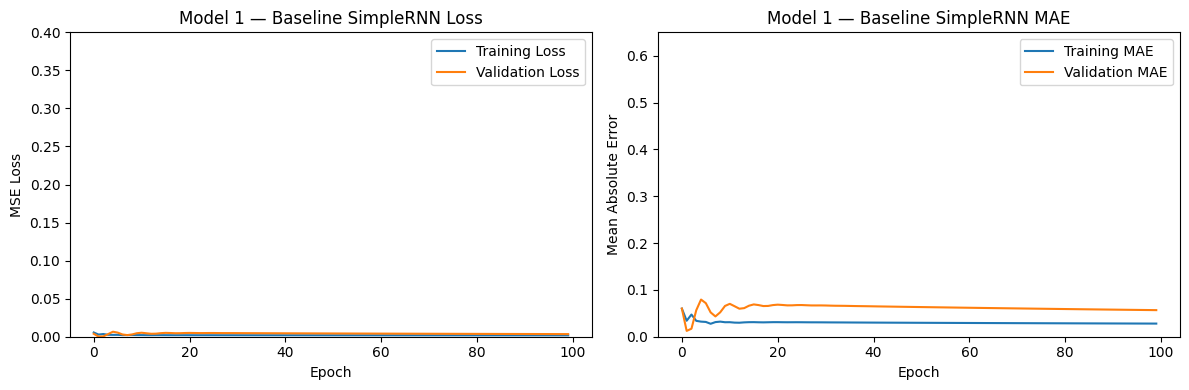

In [ ]:
plot_training_curves(history_1, "Model 1 — Baseline SimpleRNN")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Model 1 — Baseline SimpleRNN Train RMSE: 9062.45
Model 1 — Baseline SimpleRNN Test RMSE: 15821.74


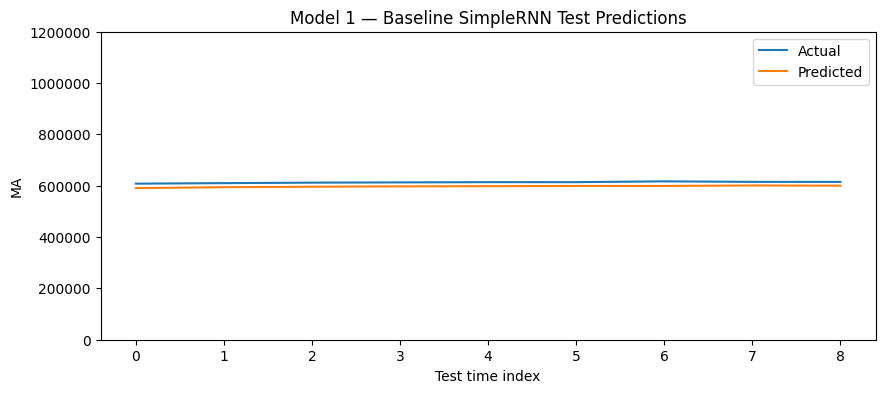

In [ ]:
evaluate_and_plot(
    model_1, trainX_1, testX_1, trainY_1, testY_1,
    scaler_3bed, "Model 1 — Baseline SimpleRNN"
)

**Model 1 Observations**

The baseline converged steadily — training and validation loss curves tracked closely throughout 100 epochs with no meaningful divergence, indicating the model is not overfit. Test RMSE of ~15,800 and MAE of ~15,778 confirm it captures the broad trend but leaves substantial error. With only a 2-step window and 16 units, the receptive field is narrow; this sets the floor that subsequent models aim to beat.

### Model 2 — Wider Look-Back + More Capacity (look\_back = 4, 32 units)

Extending the receptive field to 4 timesteps and doubling the hidden units gives the model more temporal context and representational capacity. The key question is whether the longer window helps on this series or just adds noise given the limited number of training examples.

In [ ]:
# Model 2 uses look_back=4 — re-slice sequences from the same scaled data
look_back_2 = 4

trainX_2, trainY_2 = create_sequences(train_3bed, look_back_2)
testX_2, testY_2   = create_sequences(test_3bed,  look_back_2)

print("trainX shape:", trainX_2.shape, " | testX shape:", testX_2.shape)

trainX shape: (36, 4, 1)  | testX shape: (7, 4, 1)


In [ ]:
model_2 = Sequential([
    SimpleRNN(32, activation="tanh", input_shape=(look_back_2, 1)),
    Dense(1)
])

model_2.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

history_2 = model_2.fit(
    trainX_2, trainY_2,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.4294 - mean_absolute_error: 0.6395 - val_loss: 0.7352 - val_mean_absolute_error: 0.8547
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1546 - mean_absolute_error: 0.3833 - val_loss: 0.2471 - val_mean_absolute_error: 0.4943
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0227 - mean_absolute_error: 0.1406 - val_loss: 0.0304 - val_mean_absolute_error: 0.1698
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0080 - mean_absolute_error: 0.0781 - val_loss: 0.0037 - val_mean_absolute_error: 0.0518
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0367 - mean_absolute_error: 0.1804 - val_loss: 0.0140 - val_mean_absolute_error: 0.1145
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0376 - mean_absolute_error: 0.1829 - val_loss: 0.0036 - val_mean_absolute_error: 0.0511
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0177 - mean_absolute_error: 0.1182 - val_loss: 0.0050 - val_mean

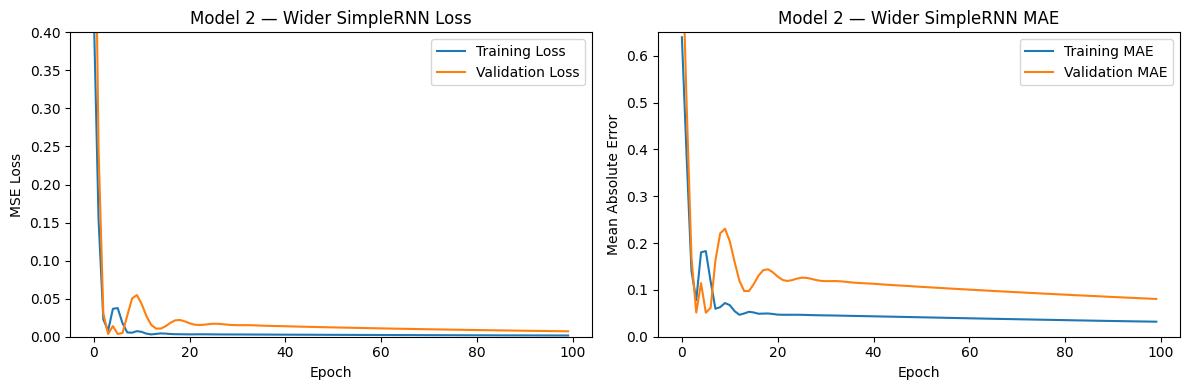

In [ ]:
plot_training_curves(history_2, "Model 2 — Wider SimpleRNN")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Model 2 — Wider SimpleRNN Train RMSE: 10383.34
Model 2 — Wider SimpleRNN Test RMSE: 21124.16


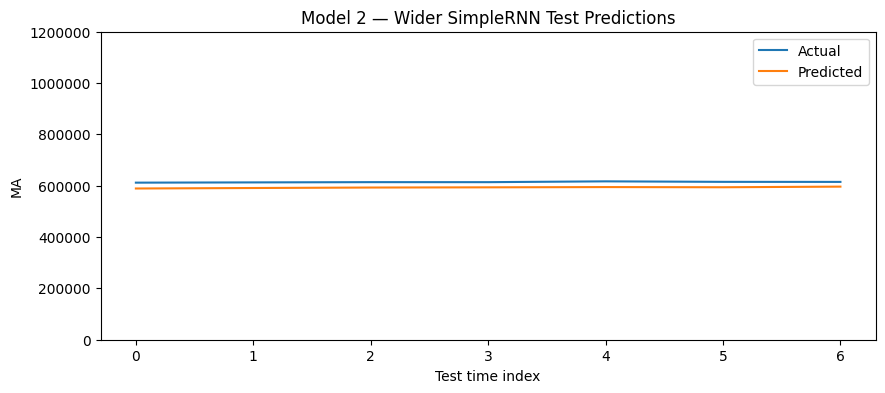

In [ ]:
evaluate_and_plot(
    model_2, trainX_2, testX_2, trainY_2, testY_2,
    scaler_3bed, "Model 2 — Wider SimpleRNN"
)

**Model 2 Observations**

Counterintuitively, adding more context and capacity made things worse — test RMSE rose from ~15,800 (M1) to ~21,100, and MAE followed the same direction. The longer look-back (4 steps) and 32 units appear to overfit on only ~36 training windows: the model memorized training patterns that did not generalize to the 7 held-out test windows. Validation loss during training was also less smooth than M1's, consistent with this interpretation. The takeaway is that more capacity without regularization or architectural depth is actively harmful at this data scale.

### Model 3 — Stacked SimpleRNN (look\_back = 4, two layers)

Stacking a second SimpleRNN layer forces the network to learn higher-order temporal abstractions. `return_sequences=True` on the first layer passes the full sequence of hidden states — not just the final step — as input to the second recurrent layer, allowing it to reason about patterns across the entire window.

In [ ]:
model_3 = Sequential([
    SimpleRNN(
        32,
        activation="tanh",
        return_sequences=True,       # pass full hidden-state sequence to next RNN layer
        input_shape=(look_back_2, 1)
    ),
    SimpleRNN(16, activation="tanh"),
    Dense(1)
])

model_3.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

history_3 = model_3.fit(
    trainX_2, trainY_2,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.0222 - mean_absolute_error: 0.1274 - val_loss: 0.0104 - val_mean_absolute_error: 0.1000
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0171 - mean_absolute_error: 0.1193 - val_loss: 0.0160 - val_mean_absolute_error: 0.1237
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0116 - mean_absolute_error: 0.0944 - val_loss: 0.0445 - val_mean_absolute_error: 0.2088
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0016 - mean_absolute_error: 0.0315 - val_loss: 0.0018 - val_mean_absolute_error: 0.0369
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0069 - mean_absolute_error: 0.0781 - val_loss: 0.0013 - val_mean_absolute_error: 0.0312
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0032 - mean_absolute_error: 0.0472 - val_loss: 0.0184 - val_mean_absolute_error: 0.1333
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0031 - mean_absolute_error: 0.0479 - val_loss: 0.0138 - val_mea

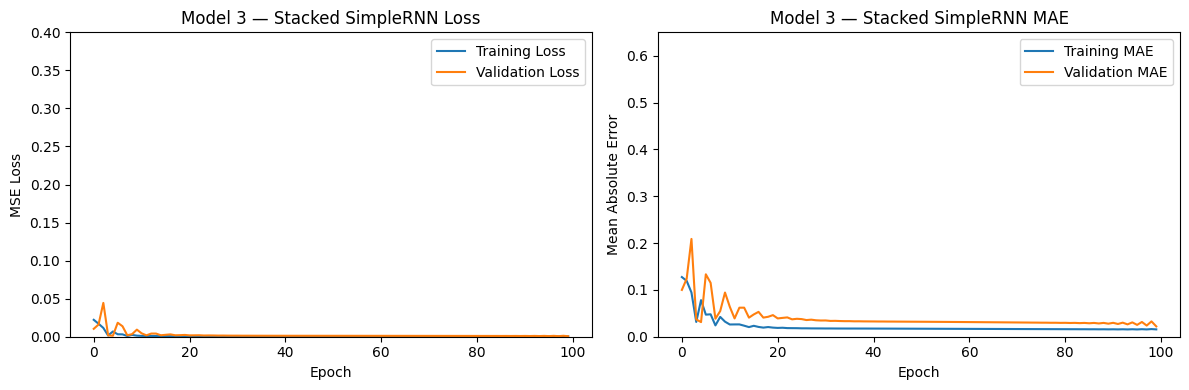

In [ ]:
plot_training_curves(history_3, "Model 3 — Stacked SimpleRNN")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Model 3 — Stacked SimpleRNN Train RMSE: 4365.28
Model 3 — Stacked SimpleRNN Test RMSE: 6109.57


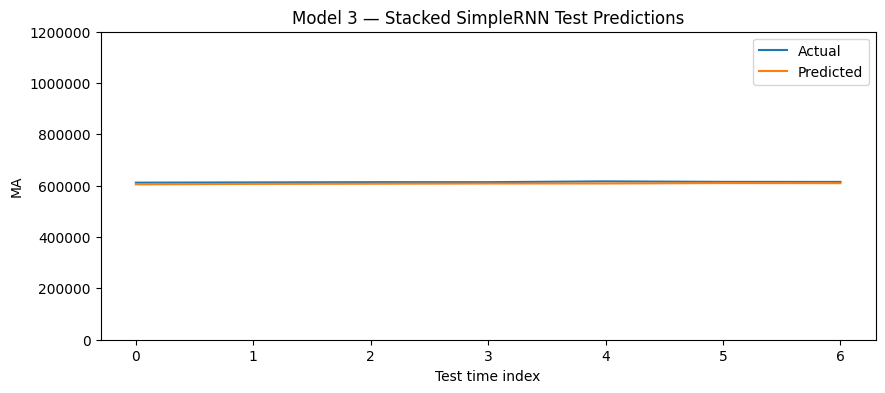

In [ ]:
evaluate_and_plot(
    model_3, trainX_2, testX_2, trainY_2, testY_2,
    scaler_3bed, "Model 3 — Stacked SimpleRNN"
)

**Model 3 Observations**

M3 was the clear best model — RMSE of ~6,100 and MAE of ~6,000, roughly 60% lower than the baseline. The stacked architecture's training curves showed the most rapid loss reduction, and validation loss remained close to training loss without diverging, so the depth did not cause the overfitting concern it raised in M2. The two-layer structure likely helped by building hierarchical representations: the first layer encodes short-term step-to-step changes, the second layer reasons about the pattern across the full 4-step window. That said, the test set contains only 7 windows, so this result should be interpreted cautiously — it may not hold under a different random seed.

### Model 4 — SimpleRNN with Dropout Regularization (look\_back = 4)

Dropout randomly zeros a fraction of hidden units during each training step, preventing the network from over-relying on any single activation path. Here we apply `Dropout(0.2)` after the RNN layer to address the overfitting risk seen in Model 3, keeping the same look-back window and unit count otherwise.

In [ ]:
model_4 = Sequential([
    SimpleRNN(32, activation="tanh", input_shape=(look_back_2, 1)),
    Dropout(0.2),                   # zero 20 % of units each training step
    Dense(1)
])

model_4.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=["mean_absolute_error"]
)

history_4 = model_4.fit(
    trainX_2, trainY_2,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.2485 - mean_absolute_error: 0.4735 - val_loss: 0.3459 - val_mean_absolute_error: 0.5855
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0591 - mean_absolute_error: 0.2060 - val_loss: 0.1027 - val_mean_absolute_error: 0.3174
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0210 - mean_absolute_error: 0.1090 - val_loss: 0.0149 - val_mean_absolute_error: 0.1163
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0273 - mean_absolute_error: 0.1427 - val_loss: 0.0011 - val_mean_absolute_error: 0.0308
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0241 - mean_absolute_error: 0.1213 - val_loss: 0.0012 - val_mean_absolute_error: 0.0287
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0353 - mean_absolute_error: 0.1567 - val_loss: 0.0022 - val_mean_absolute_error: 0.0371
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0281 - mean_absolute_error: 0.1424 - val_loss: 0.0095 - val_mea

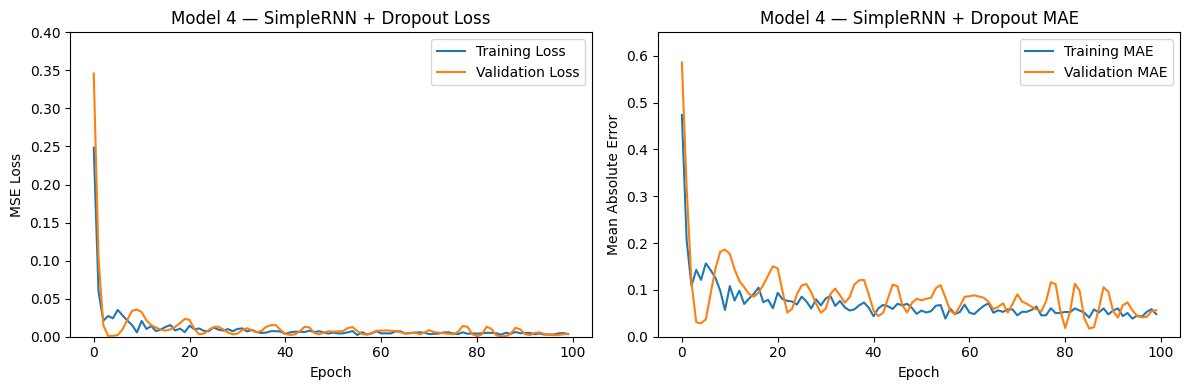

In [ ]:
plot_training_curves(history_4, "Model 4 — SimpleRNN + Dropout")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Model 4 — SimpleRNN + Dropout Train RMSE: 8113.74
Model 4 — SimpleRNN + Dropout Test RMSE: 12080.28


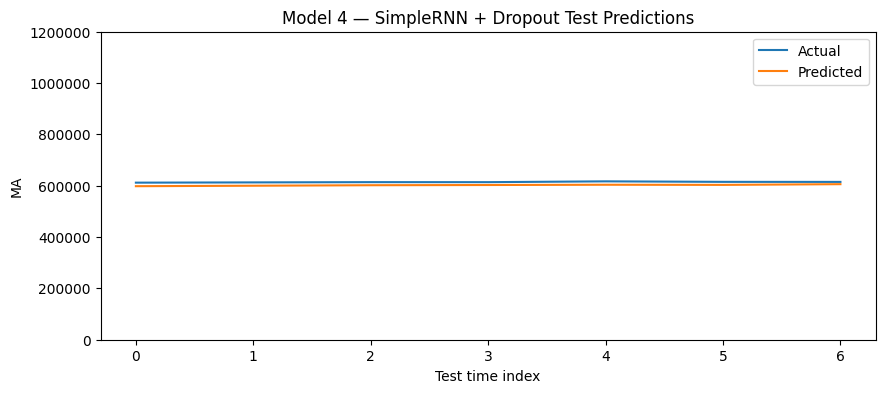

In [ ]:
evaluate_and_plot(
    model_4, trainX_2, testX_2, trainY_2, testY_2,
    scaler_3bed, "Model 4 — SimpleRNN + Dropout"
)

**Model 4 Observations**

Dropout regularization improved over M2 (RMSE dropped from ~21,100 to ~12,100), confirming that the M2 overfitting was real and that zeroing 20% of units during training was enough to partially correct it. However, M4 did not surpass M3 — its RMSE of ~12,100 is roughly double M3's. The loss curves for M4 were notably smoother and more stable than M2's, which is the expected signature of dropout working as intended. The result suggests that for this dataset, architectural depth (M3) was a more effective improvement than regularization alone (M4), though both were better than simply adding capacity without either.

In [ ]:
# Collect held-out test metrics for all four models
rmse_1, mae_1 = evaluate_metrics(model_1, testX_1, testY_1, scaler_3bed)
rmse_2, mae_2 = evaluate_metrics(model_2, testX_2, testY_2, scaler_3bed)
rmse_3, mae_3 = evaluate_metrics(model_3, testX_2, testY_2, scaler_3bed)
rmse_4, mae_4 = evaluate_metrics(model_4, testX_2, testY_2, scaler_3bed)

comparison_3bed = pd.DataFrame({
    "Model": [
        "M1: Baseline (lb=2, 16u)",
        "M2: Wider (lb=4, 32u)",
        "M3: Stacked (lb=4)",
        "M4: Dropout (lb=4, 32u)",
    ],
    "RMSE": [rmse_1, rmse_2, rmse_3, rmse_4],
    "MAE":  [mae_1,  mae_2,  mae_3,  mae_4],
})

comparison_3bed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


,Model,RMSE,MAE
0,"M1: Baseline (lb=2, 16u)",15821.742717,15777.743056
1,"M2: Wider (lb=4, 32u)",21124.158696,21080.607143
2,M3: Stacked (lb=4),6109.566002,6003.821429
3,"M4: Dropout (lb=4, 32u)",12080.281804,11981.955357


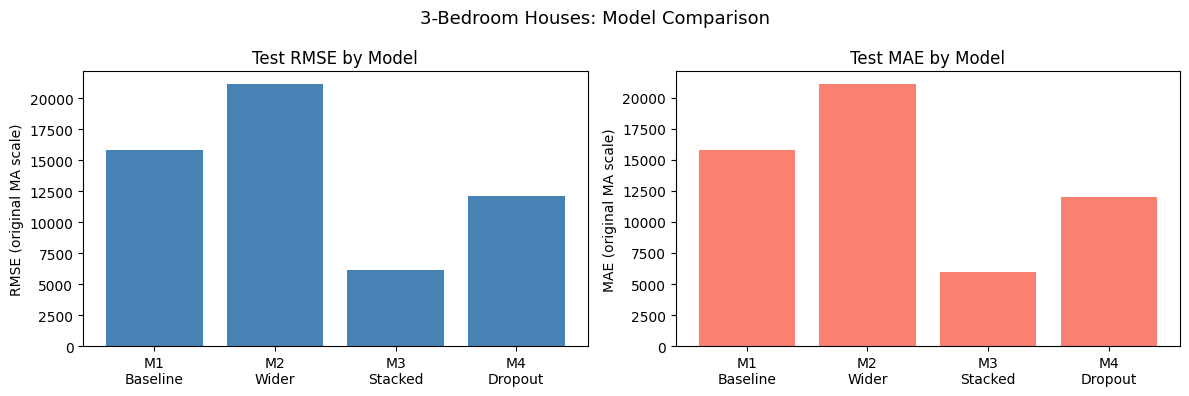

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

short_names = ["M1\nBaseline", "M2\nWider", "M3\nStacked", "M4\nDropout"]

axes[0].bar(short_names, comparison_3bed["RMSE"], color="steelblue")
axes[0].set_title("Test RMSE by Model")
axes[0].set_ylabel("RMSE (original MA scale)")
axes[0].ticklabel_format(style="plain", axis="y")

axes[1].bar(short_names, comparison_3bed["MAE"], color="salmon")
axes[1].set_title("Test MAE by Model")
axes[1].set_ylabel("MAE (original MA scale)")
axes[1].ticklabel_format(style="plain", axis="y")

plt.suptitle("3-Bedroom Houses: Model Comparison", fontsize=13)
plt.tight_layout()
plt.show()